# BERT Percobaan 1 (35% train and 65% unlabelled)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install dependency

In [1]:
# Colab sudah punya transformers/datasets/torch — cukup upgrade
!pip install -q -U transformers accelerate seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 90.4 MB/s eta 0:00:00


In [2]:
pip install tqdm -q

In [3]:
pip install -U accelerate>=0.21.0' -q

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [4]:
pip install -U transformers[torch] -q

In [5]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.6 MB/s eta 0:00:00


In [6]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, TrainingArguments, Trainer, DataCollatorForTokenClassification, AutoModelForTokenClassification, pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from shutil import rmtree
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import os

## Load and prepare datasets

In [7]:
os.getcwd()

'/content'

In [21]:
from google.colab import drive
drive.mount('/content/drive')

_name = 'bert-only'
_type = 'sirah-ner'
experiment_name = f'{_name}-{_type}'

import os
# === Colab paths (Google Drive) ===
# Upload train.csv / test.csv / unlabelled.csv ke folder Drive berikut:
dataset_dir = '/content/drive/MyDrive/TA-Sirah'
root_dir    = '/content/drive/MyDrive/TA-Sirah/output'
model_dir   = os.path.join(root_dir, 'models')
eval_dir    = os.path.join(root_dir, 'evaluation')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(eval_dir,  exist_ok=True)

df_train = pd.read_csv(os.path.join(dataset_dir, 'train.csv'))
df_train["token"] = df_train["token"].apply(str)
df_train["label"] = df_train["label"].apply(lambda x: x.replace("-", "_"))
df_train.loc[df_train[df_train.isna().any(axis=1)].index, 'token'] = 'nan'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# os.listdir(dataset_dir)
#

In [23]:
# === Smoke test: cek GPU & file ===
import torch, os
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("!! GPU tidak aktif. Runtime > Change runtime type > T4 GPU")

for f in ['train.csv', 'test.csv', 'unlabelled.csv']:
    fp = os.path.join(dataset_dir, f)
    print(f"{f:<16} ->", 'OK' if os.path.exists(fp) else 'MISSING', fp)


CUDA available : True
GPU            : Tesla T4
train.csv        -> OK /content/drive/MyDrive/TA-Sirah/train.csv
test.csv         -> OK /content/drive/MyDrive/TA-Sirah/test.csv
unlabelled.csv   -> OK /content/drive/MyDrive/TA-Sirah/unlabelled.csv


In [24]:
# # Cek indeks baris dengan NaN di kolom 'token'
# nan_token_indices = df_train[df_train["token"].isna()].index
# print("Indeks baris dengan NaN di kolom 'token':", nan_token_indices)

# # Cek indeks baris dengan NaN di kolom 'entity'
# nan_entity_indices = df_train[df_train["label"].isna()].index
# print("Indeks baris dengan NaN di kolom 'label':", nan_entity_indices)


In [25]:
label_list = sorted(df_train['label'].unique(),key=lambda name: (name[1:], name[0]))
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {v: k for k, v in id2label.items()}

id2label

{0: 'O',
 1: 'B_EVENT',
 2: 'I_EVENT',
 3: 'B_LOCATION',
 4: 'I_LOCATION',
 5: 'B_PERSON',
 6: 'I_PERSON',
 7: 'B_TIME',
 8: 'I_TIME'}

## Tokenize and split dataset into train and validation

In [26]:
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased", model_max_length=512)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples['tokens'], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples['label']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Map tokens to their respective word.
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:  # Set the special tokens to -100.
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:  # Only label the first token of a given word.
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

def df_to_dataset_for_model(df: pd.DataFrame):
  # So the original df remains unchanged
  df = df.copy(deep=True)

  # Mengganti NaN dengan label default, misalnya 'O'
  df["label"] = df["label"].fillna('O')

  # Apply label2id mapping
  df["label"] = df["label"].apply(lambda x: label2id[x])

  # Merge tokens into full sentence
  tmp_df = df.groupby("text_id")["token"].apply(list).reset_index()
  tmp_df["label"] = df.groupby("text_id")["label"].apply(list).reset_index()["label"]
  tmp_df.columns = ["text_id", "tokens", "label"]

  # Convert to Dataset format
  tmp_list = []
  for i in tmp_df.index:
    tmp_list.append({
        "text_id": tmp_df.loc[i, "text_id"],
        "tokens": tmp_df.loc[i, "tokens"],
        "label": tmp_df.loc[i, "label"],
    })

  dataset = Dataset.from_list(tmp_list)

  # Tokenize the dataset
  tokenized_dataset = dataset.map(tokenize_and_align_labels,
                                  batched=True,
                                  remove_columns=dataset.column_names)

  # Split into train and validation
  train_val = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
  train_val = DatasetDict({
      "train": train_val["train"],
      "validation": train_val["test"]
  })

  return train_val

# def df_to_dataset_for_model(df: pd.DataFrame):
#   # So the original df remains unchanged
#   df = df.copy(deep=True)
#   df["label"] = df["label"].apply(lambda x: label2id[x])

#   # Merge tokens into full sentence
#   tmp_df = df.groupby("text_id")["token"].apply(list).reset_index()
#   tmp_df["label"] = df.groupby("text_id")["label"].apply(list).reset_index()["label"]
#   tmp_df.columns = ["text_id", "tokens", "label"]

#   # Convert to Dataset format
#   tmp_list = []
#   for i in tmp_df.index:
#     tmp_list.append({
#         "text_id": tmp_df.loc[i, "text_id"],
#         "tokens": tmp_df.loc[i, "tokens"],
#         "label": tmp_df.loc[i, "label"],
#     })

#   dataset = Dataset.from_list(tmp_list)

#   # Tokenize the dataset
#   tokenized_dataset = dataset.map(tokenize_and_align_labels,
#                                   batched=True,
#                                   remove_columns=dataset.column_names)

#   # Split into train and validation
#   train_val = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
#   train_val = DatasetDict({
#       "train": train_val["train"],
#       "validation": train_val["test"]
#   })

#   return train_val

In [27]:
train_val = df_to_dataset_for_model(df_train)
print(train_val)

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 472
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 118
    })
})


## Begin training base model

In [37]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def compute_metrics(pred):
    # Get the predictions and the true labels
    labels = pred.label_ids
    predictions = np.argmax(pred.predictions, axis=2)

    # Remove ignored index (often -100) from the labels and predictions
    true_labels = [[l for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]
    true_predictions = [[p for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]

    # Flatten the lists to pass to sklearn
    true_labels = [item for sublist in true_labels for item in sublist]
    true_predictions = [item for sublist in true_predictions for item in sublist]

    # Calculate precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, true_predictions, average='weighted', zero_division=0)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

def train_model(model_name: str,
                train_dataset: Dataset,
                val_dataset: Dataset,
                model_output_path: str):

  training_args = TrainingArguments(
    output_dir=os.path.join(model_dir, "_trainer_tmp"),
    # overwrite_output_dir = True,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    seed=42,
  )

  def model_init():
    return AutoModelForTokenClassification.from_pretrained(model_name, id2label=id2label, label2id=label2id)

  trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
  )

  trainer.train()
  trainer.save_model(model_output_path)

  rmtree(os.path.join(model_dir, "_trainer_tmp"), ignore_errors=True)

In [38]:
train_model(model_name="indolem/indobert-base-uncased",
            train_dataset=train_val["train"],
            val_dataset=train_val["validation"],
            model_output_path=os.path.join(model_dir, f"{experiment_name}-base"))


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly in

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly in

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.117971,0.957705,0.964872,0.957632
2,No log,0.053619,0.980647,0.983571,0.981990
3,No log,0.038496,0.988137,0.987962,0.987817
4,No log,0.033275,0.990098,0.989837,0.989867
5,No log,0.038893,0.989177,0.987962,0.988349
6,No log,0.030173,0.991267,0.991119,0.991160
7,No log,0.031127,0.991333,0.991021,0.991135
8,No log,0.029668,0.992132,0.991958,0.992025
9,No log,0.030936,0.991734,0.991415,0.991533
10,No log,0.030181,0.992007,0.991761,0.991852


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Run the model on unlabelled data

In [39]:
def extract_entities_from_result(tokens, result):
  predicted_entities = []

  current_index = 0
  for token in tokens:
    predicted = "O"
    for entry in result:
      if entry["start"] <= current_index < entry["end"]:
        predicted = f"{entry['entity_group']}"
    predicted_entities.append(predicted)
    current_index += len(token) + 1

  return predicted_entities


def filter_threshold(model_path: str,
                     df: pd.DataFrame,
                     threshold: float,
                     output_dir: str,
                     output_filename_prefix: str):
  # if file exist, just continue
  if os.path.exists(os.path.join(dataset_dir, f"{output_filename_prefix}-above-{threshold}-retraining.csv")):
    tmp_df = pd.read_csv(os.path.join(dataset_dir, f"{output_filename_prefix}-above-{threshold}-retraining.csv"))
    tmp_df["token"] = tmp_df["token"].apply(str)
    return tmp_df

  # Load base model
  ner = pipeline("token-classification",
                 model=model_path,
                 aggregation_strategy="simple")

  # above and below are for evaluation
  above = {
      'text_id': [],
      'text': [],
      'predicted_label': [],
      'word': [],
      'confidence': [],
  }

  below = {
      'text_id': [],
      'text': [],
      'predicted_label': [],
      'word': [],
      'confidence': [],
  }

  # predicted above is the one to be returned
  predicted_above = {
      'text_id': [],
      'tokens': [],
      'predicted_label': [],
  }

  # Get all text ids of unlabelled data
  text_ids = df["text_id"].unique().tolist()
  for text_id in tqdm(text_ids):
    tokens = df[df["text_id"] == text_id]["token"].to_list()
    text = " ".join(tokens)
    result = ner(text)

    if len(result) == 0:
      below["text_id"].append(text_id)
      below["text"].append(text)
      below["predicted_label"].append("-")
      below["word"].append("-")
      below["confidence"].append(0)
      continue

    score = 0
    for entity in result:
      score += entity["score"]
    avg = score / len(result)

    # Filter above and below average
    if avg >= threshold:
      predicted_above["text_id"].append(text_id)
      predicted_above["tokens"].append(tokens)
      predicted_above["predicted_label"].append(extract_entities_from_result(tokens, result))

      for entity in result:
        above["text_id"].append(text_id)
        above["text"].append(text)
        above["predicted_label"].append(entity["entity_group"])
        above["word"].append(entity["word"])
        above["confidence"].append(entity["score"])
    else:
      for entity in result:
        below["text_id"].append(text_id)
        below["text"].append(text)
        below["predicted_label"].append(entity["entity_group"])
        below["word"].append(entity["word"])
        below["confidence"].append(entity["score"])

  above_df = pd.DataFrame(above)
  below_df = pd.DataFrame(below)

  above_df.to_excel(os.path.join(output_dir, f"{output_filename_prefix}-above-{threshold}.xlsx"))
  below_df.to_excel(os.path.join(output_dir, f"{output_filename_prefix}-below-{threshold}.xlsx"))

  print(f"Above {threshold}: {len(above_df['text_id'].unique())} sentences")
  print(f"Below {threshold}: {len(below_df['text_id'].unique())} sentences")

  predicted_above = pd.DataFrame(predicted_above)
  predicted_above = predicted_above.explode(["tokens", "predicted_label"]).reset_index(drop=True)
  predicted_above.columns = ["text_id", "token", "predicted_label"]
  predicted_above.to_csv(os.path.join(dataset_dir, f"{output_filename_prefix}-above-{threshold}-retraining.csv"), index=False)

  return predicted_above

### Confidence threshold 0.8

In [40]:
df_unlabelled = pd.read_csv(os.path.join(dataset_dir, 'unlabelled.csv'))
df_unlabelled["token"] = df_unlabelled["token"].apply(str)

In [41]:
# # Cek indeks baris dengan NaN di kolom 'token'
# nan_token_indices3 = df_unlabelled[df_unlabelled["token"].isna()].index
# print("Indeks baris dengan NaN di kolom 'token':", nan_token_indices3)

In [42]:

above_09_df = filter_threshold(
    model_path=os.path.join(model_dir, f"{experiment_name}-base"),
    df=df_unlabelled,
    threshold=0.9,
    output_dir=eval_dir,
    output_filename_prefix="bert-only-sirah-ner"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:08<00:00, 30.52it/s]


Above 0.9: 157 sentences
Below 0.9: 93 sentences


In [43]:
train_val_09 = df_to_dataset_for_model(pd.concat([df_train, above_09_df]))
print(train_val_09)

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 597
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})


In [44]:
train_model(model_name=os.path.join(model_dir, f"{experiment_name}-base"),
            train_dataset=train_val_09["train"],
            val_dataset=train_val_09["validation"],
            model_output_path=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-2"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.054433,0.980931,0.975898,0.977532
2,No log,0.052770,0.981897,0.976902,0.978459
3,No log,0.055206,0.980539,0.977134,0.978289
4,No log,0.055229,0.980757,0.977868,0.978881
5,No log,0.058226,0.978083,0.977713,0.977782
6,No log,0.074170,0.981207,0.977984,0.979088
7,No log,0.071685,0.980386,0.978254,0.979046
8,No log,0.079306,0.979777,0.977829,0.978564
9,No log,0.095821,0.981205,0.977095,0.978453
10,No log,0.091498,0.980896,0.977289,0.978512


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [45]:
df_unlabelled_2 = pd.read_excel(os.path.join(eval_dir, "bert-only-sirah-ner-below-0.9.xlsx"))
df_unlabelled_2 = df_unlabelled_2.drop(columns=['confidence', 'predicted_label'])
df_unlabelled_2 = df_unlabelled_2.rename(columns={'word':'token'})
df_unlabelled_2 = df_unlabelled_2.drop_duplicates()

In [46]:
print(above_09_df)

          text_id        token predicted_label
0      000021-002     berkata,               O
1      000021-002  "Biarkanlah               O
2      000021-002       anakku               O
3      000021-002         ini.               O
4      000021-002         Demi               O
...           ...          ...             ...
26490  000326-002          itu               O
26491  000326-002       adalah               O
26492  000326-002         para               O
26493  000326-002    malaikat,               O
26494  000326-002        pent.               O

[26495 rows x 3 columns]


In [47]:
print(df_unlabelled_2)

     Unnamed: 0     text_id  \
0             0  000019-005   
1             1  000043-001   
2             2  000043-001   
3             3  000043-001   
4             4  000043-001   
..          ...         ...   
774         774  000349-002   
775         775  000349-002   
776         776  000349-002   
777         777  000349-002   
778         778  000349-002   

                                                  text       token  
0    Aku tidak pernah melihat sepetak tanah pun yan...           -  
1    Langkah pertama yang dilakukan Rasulullah sete...  rasulullah  
2    Langkah pertama yang dilakukan Rasulullah sete...          al  
3    Langkah pertama yang dilakukan Rasulullah sete...     muththa  
4    Langkah pertama yang dilakukan Rasulullah sete...        ##li  
..                                                 ...         ...  
774  Ia mencintai kami dan kami mencintainya." Seca...       rajab  
775  Ia mencintai kami dan kami mencintainya." Seca...       bulan  
776  I

In [48]:
above_09_df_2 = filter_threshold(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-2"),
    df=df_unlabelled_2,
    threshold=0.9,
    output_dir=os.path.join(eval_dir),
    output_filename_prefix="bert-only-sirah-ner-iterative-2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 93/93 [00:01<00:00, 83.79it/s]


Above 0.9: 0 sentences
Below 0.9: 93 sentences


In [49]:
train_val_09 = df_to_dataset_for_model(pd.concat([df_train, above_09_df, above_09_df_2]))
print(train_val_09)

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 597
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})


In [50]:
train_model(model_name=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-2"),
            train_dataset=train_val_09["train"],
            val_dataset=train_val_09["validation"],
            model_output_path=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-3"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.055562,0.980966,0.976786,0.978182
2,No log,0.068825,0.980998,0.977095,0.978400
3,No log,0.062779,0.975916,0.976246,0.975947
4,No log,0.077886,0.981026,0.976748,0.978162
5,No log,0.076550,0.978904,0.977289,0.977924
6,No log,0.090424,0.981139,0.978061,0.979126
7,No log,0.089257,0.980864,0.978254,0.979188
8,No log,0.096641,0.980141,0.977636,0.978549
9,No log,0.114012,0.981477,0.977520,0.978831
10,No log,0.109817,0.981006,0.977366,0.978600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [51]:
df_unlabelled_3 = pd.read_excel(os.path.join(eval_dir, "bert-only-sirah-ner-iterative-2-below-0.9.xlsx"))
df_unlabelled_3 = df_unlabelled_3.drop(columns=['confidence', 'predicted_label'])
df_unlabelled_3 = df_unlabelled_3.rename(columns={'word':'token'})
df_unlabelled_3 = df_unlabelled_3.drop_duplicates()

In [52]:
above_09_df_3 = filter_threshold(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-3"),
    df=df_unlabelled_3,
    threshold=0.9,
    output_dir=os.path.join(eval_dir),
    output_filename_prefix="bert-only-sirah-ner-iterative-3"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 93/93 [00:01<00:00, 84.05it/s]

Above 0.9: 0 sentences
Below 0.9: 93 sentences


In [53]:
train_val_09 = df_to_dataset_for_model(pd.concat([df_train, above_09_df, above_09_df_2, above_09_df_3]))
print(train_val_09)

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 597
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})


In [54]:
train_model(model_name=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-3"),
            train_dataset=train_val_09["train"],
            val_dataset=train_val_09["validation"],
            model_output_path=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-4"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.083316,0.981764,0.976632,0.978244
2,No log,0.074676,0.980908,0.977134,0.978397
3,No log,0.071583,0.975706,0.975782,0.975617
4,No log,0.089610,0.981643,0.977404,0.978788
5,No log,0.083289,0.979039,0.977057,0.977826
6,No log,0.112826,0.982501,0.978216,0.979579
7,No log,0.101529,0.981602,0.978293,0.979419
8,No log,0.103717,0.980468,0.977829,0.978779
9,No log,0.119514,0.981855,0.978061,0.979319
10,No log,0.117349,0.981419,0.977829,0.979040


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [55]:
df_unlabelled_4 = pd.read_excel(os.path.join(eval_dir, "bert-only-sirah-ner-iterative-3-below-0.9.xlsx"))
df_unlabelled_4 = df_unlabelled_4.drop(columns=['confidence', 'predicted_label'])
df_unlabelled_4 = df_unlabelled_4.rename(columns={'word':'token'})
df_unlabelled_4 = df_unlabelled_4.drop_duplicates()

In [56]:
above_09_df_4 = filter_threshold(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-4"),
    df=df_unlabelled_4,
    threshold=0.9,
    output_dir=os.path.join(eval_dir),
    output_filename_prefix="bert-only-sirah-ner-iterative-4"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 93/93 [00:01<00:00, 83.19it/s]


Above 0.9: 0 sentences
Below 0.9: 93 sentences


In [57]:
train_val_09 = df_to_dataset_for_model(pd.concat([df_train, above_09_df, above_09_df_2, above_09_df_3, above_09_df_4]))
print(train_val_09)

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 597
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})


In [58]:
train_model(model_name=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-4"),
            train_dataset=train_val_09["train"],
            val_dataset=train_val_09["validation"],
            model_output_path=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-5"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.122809,0.980325,0.974817,0.976579
2,No log,0.118616,0.981240,0.976671,0.978154
3,No log,0.110106,0.979609,0.976246,0.977437
4,No log,0.110455,0.980725,0.977018,0.978279
5,No log,0.113665,0.978953,0.975898,0.977009
6,No log,0.148850,0.981724,0.976014,0.977803
7,No log,0.121390,0.980513,0.977057,0.978257
8,No log,0.131349,0.979967,0.976671,0.977837
9,No log,0.139272,0.980388,0.976748,0.978003
10,No log,0.140508,0.980418,0.976825,0.978065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
df_unlabelled_5 = pd.read_excel(os.path.join(eval_dir, "bert-only-sirah-ner-iterative-4-below-0.9.xlsx"))
df_unlabelled_5 = df_unlabelled_5.drop(columns=['confidence', 'predicted_label'])
df_unlabelled_5 = df_unlabelled_5.rename(columns={'word':'token'})
df_unlabelled_5 = df_unlabelled_5.drop_duplicates()

In [60]:
above_09_df_5 = filter_threshold(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-5"),
    df=df_unlabelled_5,
    threshold=0.9,
    output_dir=os.path.join(eval_dir),
    output_filename_prefix="bert-only-sirah-ner-iterative-5"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 93/93 [00:02<00:00, 46.34it/s]

Above 0.9: 0 sentences
Below 0.9: 93 sentences


In [61]:
train_val_09 = df_to_dataset_for_model(pd.concat([df_train, above_09_df, above_09_df_2, above_09_df_3, above_09_df_4,above_09_df_5]))
print(train_val_09)

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 597
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 150
    })
})


In [62]:
train_model(model_name=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-5"),
            train_dataset=train_val_09["train"],
            val_dataset=train_val_09["validation"],
            model_output_path=os.path.join(model_dir, f"{experiment_name}-0.9-iteration-6"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,No log,0.102382,0.978647,0.976014,0.976960
2,No log,0.156518,0.981541,0.975396,0.977280
3,No log,0.145881,0.980554,0.975937,0.977465
4,No log,0.106361,0.979206,0.977289,0.978026
5,No log,0.116227,0.979269,0.976748,0.977687
6,No log,0.157522,0.981652,0.976130,0.977875
7,No log,0.130590,0.980432,0.977211,0.978350
8,No log,0.141252,0.979731,0.976516,0.977672
9,No log,0.149337,0.979960,0.976516,0.977731
10,No log,0.149832,0.980000,0.976555,0.977768


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [63]:
df_unlabelled_6 = pd.read_excel(os.path.join(eval_dir, "bert-only-sirah-ner-iterative-5-below-0.9.xlsx"))
df_unlabelled_6 = df_unlabelled_6.drop(columns=['confidence', 'predicted_label'])
df_unlabelled_6 = df_unlabelled_6.rename(columns={'word':'token'})
df_unlabelled_6 = df_unlabelled_6.drop_duplicates()

In [64]:
above_09_df_6 = filter_threshold(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-6"),
    df=df_unlabelled_6,
    threshold=0.9,
    output_dir=os.path.join(eval_dir),
    output_filename_prefix="bert-only-sirah-ner-iterative-6"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 93/93 [00:01<00:00, 56.62it/s]


Above 0.9: 0 sentences
Below 0.9: 93 sentences


## Evaluate model performance

In [65]:
def get_predicted_label_on_test_dataset(model_path: str, df: pd.DataFrame):
  # Load model
  ner = pipeline("token-classification",
                 model=model_path,
                 aggregation_strategy="simple")

  predicted = []
  text_ids = df["text_id"].unique().tolist()

  for text_id in tqdm(text_ids):
    tokens = df[df["text_id"] == text_id]["token"].to_list()
    text = " ".join(tokens)
    result = ner(text)

    predicted.extend(extract_entities_from_result(tokens, result))

  df["predicted_label"] = predicted

def get_overall_performance(df: pd.DataFrame):
  # Overall accuracy
  total = len(df)
  correct = (df["label"] == df["predicted_label"]).sum()

  accuracy = (correct / total)

  print("Accuracy:", accuracy)

  # Precision, recall, and F1-score
  y_true = df['label']
  y_pred = df['predicted_label']

  precision = precision_score(y_true, y_pred, average='weighted', labels=label_list)
  recall = recall_score(y_true, y_pred, average='weighted', labels=label_list)
  f1 = f1_score(y_true, y_pred, average='weighted', labels=label_list)

  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

def get_individual_label_score(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  report = classification_report(y_true, y_pred, labels=label_list, output_dict=True)
  return pd.DataFrame(report).transpose()

def get_confusion_matrix(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  cm = confusion_matrix(y_true, y_pred, labels=label_list)
  ax= plt.subplot()
  sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Oranges", vmin=0, vmax=160)  #annot=True to annotate cells, ftm='g' to disable scientific notation

  ax.set_xlabel('Predicted labels')
  ax.set_ylabel('True labels')
  ax.set_title('Confusion Matrix')
  plt.xticks(rotation=270)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(label_list)
  ax.yaxis.set_ticklabels(label_list)

def get_misclassified_report(df: pd.DataFrame, output_path: str):

  misclassified_dict = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label != pred_label:
      misclassified_dict['token'].append(df.loc[i, 'token'])
      misclassified_dict['text_id'].append(text_id)
      misclassified_dict['true_label'].append(true_label)
      misclassified_dict['pred_label'].append(pred_label)
      misclassified_dict['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  misclassified_df = pd.DataFrame.from_dict(misclassified_dict)
  misclassified_df.to_excel(output_path)

In [66]:
def get_correct_and_incorrect_classification(df: pd.DataFrame, output_prefix: str):
  correct = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  incorrect = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label == pred_label:
      correct['token'].append(df.loc[i, 'token'])
      correct['text_id'].append(text_id)
      correct['true_label'].append(true_label)
      correct['pred_label'].append(pred_label)
      correct['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))
    else:
      incorrect['token'].append(df.loc[i, 'token'])
      incorrect['text_id'].append(text_id)
      incorrect['true_label'].append(true_label)
      incorrect['pred_label'].append(pred_label)
      incorrect['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  correct_df = pd.DataFrame.from_dict(correct)
  correct_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-correct.xlsx"))

  incorrect_df = pd.DataFrame.from_dict(incorrect)
  incorrect_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-incorrect.xlsx"))

In [67]:
df_test = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test["label"] = df_test["label"].apply(lambda x: x.replace("-", "_"))

get_predicted_label_on_test_dataset(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-6"),
    df=df_test,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 254/254 [00:08<00:00, 28.62it/s]


In [68]:
get_overall_performance(df_test)
get_individual_label_score(df_test)

Accuracy: 0.9867024351888254
Precision: 0.9864831761034767
Recall: 0.9867024351888254
F1 Score: 0.9863885526774098


,precision,recall,f1-score,support
O,0.990282,0.996189,0.993227,40407.000000
B_EVENT,0.825397,0.825397,0.825397,63.000000
I_EVENT,0.890625,0.791667,0.838235,72.000000
B_LOCATION,0.949875,0.900238,0.924390,421.000000
I_LOCATION,0.866667,1.000000,0.928571,26.000000
B_PERSON,0.938144,0.857681,0.896110,1061.000000
I_PERSON,0.946731,0.805355,0.870339,971.000000
B_TIME,0.870130,0.943662,0.905405,71.000000
I_TIME,0.853659,0.939597,0.894569,149.000000
accuracy,0.986702,0.986702,0.986702,0.986702


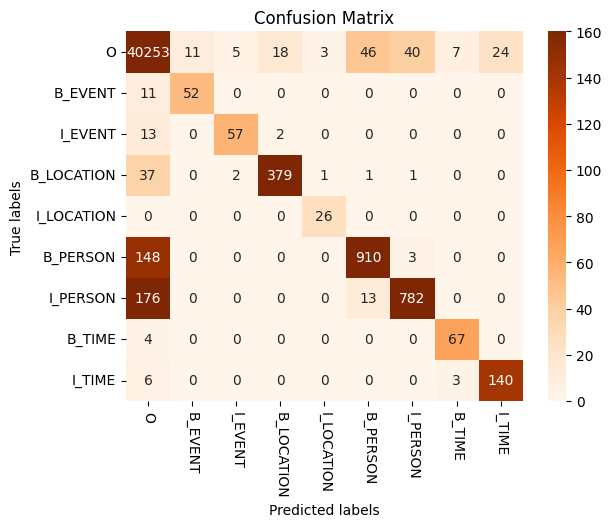

In [69]:
get_confusion_matrix(df_test)

In [70]:
get_misclassified_report(df_test, os.path.join(eval_dir, "bert-only-sirah-ner-confidence-0.9-misclassified.xlsx"))

100%|██████████| 43241/43241 [00:03<00:00, 13323.12it/s]


In [71]:
get_correct_and_incorrect_classification(df_test, "bert-only-sirah-ner-iterative-6")

100%|██████████| 43241/43241 [03:06<00:00, 231.97it/s]


In [72]:
df_test_base = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test_base["label"] = df_test_base["label"].apply(lambda x: x.replace("-", "_"))

get_predicted_label_on_test_dataset(
    model_path=os.path.join(model_dir , f"{experiment_name}-base"),
    df=df_test_base,
)

Loading weights:   0%|          | 0/199 [00:03<?, ?it/s]

100%|██████████| 254/254 [00:06<00:00, 38.48it/s]


In [73]:
get_overall_performance(df_test_base)
get_individual_label_score(df_test_base)

Accuracy: 0.9918364515159224
Precision: 0.9919397323301274
Recall: 0.9918364515159224
F1 Score: 0.9918732414099545


,precision,recall,f1-score,support
O,0.996778,0.995323,0.996050,40407.000000
B_EVENT,0.888889,0.888889,0.888889,63.000000
I_EVENT,0.907692,0.819444,0.861314,72.000000
B_LOCATION,0.927400,0.940618,0.933962,421.000000
I_LOCATION,0.920000,0.884615,0.901961,26.000000
B_PERSON,0.924144,0.941565,0.932773,1061.000000
I_PERSON,0.933000,0.960865,0.946728,971.000000
B_TIME,0.855263,0.915493,0.884354,71.000000
I_TIME,0.891026,0.932886,0.911475,149.000000
accuracy,0.991836,0.991836,0.991836,0.991836
